In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Question 3: Is there a relationship between the player rank and the number of comebacks?
 (In this question, a comeback is when they are more than two games behind in a set, they win the set, or when they lose the first set, they win the match.)

Total player-match appearances in a comeback situation: 13,276
  
Comeback Rate by Player Rank Group
  (situations = games 2+ behind in set OR lost set 1)
  (converted  = won that set OR won the match)
rank_group  total_situations  total_converted  comeback_rate
      1-10               258               55          21.32
     11-25               465               81          17.42
     26-50               794              131          16.50
    51-100              1674              249          14.87
   101-200              3244              529          16.31
   201-500              8513             1444          16.96
      500+             14686             1747          11.90


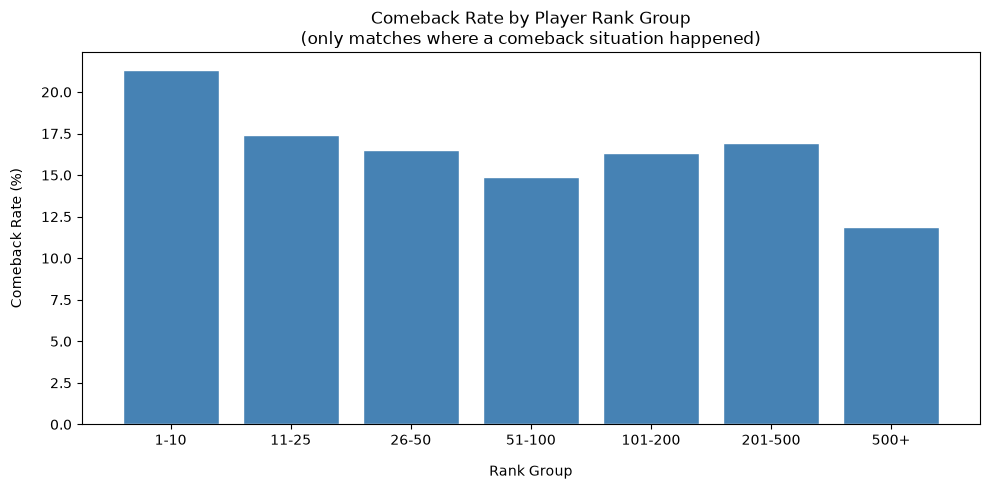

In [ ]:
pbp_df = pd.read_csv("../pbp.csv")
home_score_df  = pd.read_csv("../home_team_score.csv")
away_score_df  = pd.read_csv("../away_team_score.csv")
home_team_df   = pd.read_csv("../home_team.csv")
away_team_df   = pd.read_csv("../away_team.csv")
match_event_df = pd.read_csv("../event.csv")


pbp_df = pbp_df.dropna(subset=["match_id", "set_id", "game_id"])
pbp_df = pbp_df.dropna(subset=["set_id", "game_id"])
pbp_df = pbp_df[pbp_df["set_id"].between(1, 5)]
pbp_df = pbp_df[pbp_df["game_id"] > 0]
pbp_df = pbp_df.dropna(subset=["home_score", "away_score"])
pbp_df = pbp_df[(pbp_df["home_score"] >= 0) & (pbp_df["away_score"] >= 0)]
pbp_df = pbp_df.drop_duplicates(subset=["match_id", "set_id", "game_id", "point_id"])


period_cols = ["period_1", "period_2", "period_3", "period_4", "period_5"]
home_score_df = home_score_df.dropna(subset=["match_id"]).drop_duplicates(subset=["match_id"])
away_score_df = away_score_df.dropna(subset=["match_id"]).drop_duplicates(subset=["match_id"])


match_event_df = match_event_df[["match_id", "winner_code"]].copy()
match_event_df = match_event_df.dropna(subset=["match_id", "winner_code"])
match_event_df = match_event_df[match_event_df["winner_code"].isin([1, 2])]
match_event_df = match_event_df.drop_duplicates(subset=["match_id"])


home_team_df = home_team_df[["match_id", "current_rank"]].copy()
away_team_df = away_team_df[["match_id", "current_rank"]].copy()
for df_ in [home_team_df, away_team_df]:
    df_.dropna(subset=["match_id", "current_rank"], inplace=True)
home_team_df = home_team_df[home_team_df["current_rank"] > 0].drop_duplicates(subset=["match_id"])
away_team_df = away_team_df[away_team_df["current_rank"] > 0].drop_duplicates(subset=["match_id"])


last_point_per_game = (pbp_df
    .sort_values(["match_id", "set_id", "game_id", "point_id"])
    .groupby(["match_id", "set_id", "game_id"])
    .last()
    .reset_index()
    [["match_id", "set_id", "game_id", "home_score", "away_score"]])

set_game_stats = (last_point_per_game
    .assign(
        home_deficit=lambda d: d["away_score"] - d["home_score"],
        away_deficit=lambda d: d["home_score"] - d["away_score"])
    .groupby(["match_id", "set_id"])
    .agg(
        max_home_deficit=("home_deficit", "max"),
        max_away_deficit=("away_deficit", "max"),
        final_home_games=("home_score",   "last"),
        final_away_games=("away_score",   "last"))
    .reset_index())

set_game_stats["home_won_set"] = (
    set_game_stats["final_home_games"] > set_game_stats["final_away_games"])


#    TYPE 1 — SITUATION & CONVERSION AT SET LEVEL
#    Situation : player was 2+ games behind in the set
#    Conversion: player won that set despite the deficit

home_set_situations = set_game_stats.assign(
    home_in_situation=lambda d: d["max_home_deficit"] >= 2,
    home_converted=lambda d: (d["max_home_deficit"] >= 2) & d["home_won_set"])

away_set_situations = set_game_stats.assign(
    away_in_situation=lambda d: d["max_away_deficit"] >= 2,
    away_converted=lambda d: (d["max_away_deficit"] >= 2) & ~d["home_won_set"])

type1_home = (
    home_set_situations
    .groupby("match_id")
    .agg(
        home_t1_situations=("home_in_situation", "sum"),
        home_t1_converted=("home_converted",     "sum"))
    .reset_index())
type1_away = (
    away_set_situations
    .groupby("match_id")
    .agg(
        away_t1_situations=("away_in_situation", "sum"),
        away_t1_converted=("away_converted",     "sum"))
    .reset_index())


#    TYPE 2 — SITUATION & CONVERSION AT MATCH LEVEL
#    Situation : player lost set 1
#    Conversion: player won the match

set_scores = (
    home_score_df[["match_id", "period_1"]]
    .merge(
        away_score_df[["match_id", "period_1"]],
        on="match_id",
        suffixes=("_home", "_away"))
    .dropna(subset=["period_1_home", "period_1_away"])
    .merge(match_event_df, on="match_id", how="inner"))

set_scores["home_t2_situation"] = (
    set_scores["period_1_home"] < set_scores["period_1_away"]
).astype(int)
set_scores["home_t2_converted"] = (
    (set_scores["period_1_home"] < set_scores["period_1_away"]) &
    (set_scores["winner_code"] == 1)
).astype(int)

set_scores["away_t2_situation"] = (
    set_scores["period_1_away"] < set_scores["period_1_home"]
).astype(int)
set_scores["away_t2_converted"] = (
    (set_scores["period_1_away"] < set_scores["period_1_home"]) &
    (set_scores["winner_code"] == 2)
).astype(int)

type2_per_match = set_scores[[
    "match_id",
    "home_t2_situation", "home_t2_converted",
    "away_t2_situation", "away_t2_converted"]]


comebacks = (
    type1_home
    .merge(type1_away,      on="match_id", how="outer")
    .merge(type2_per_match, on="match_id", how="outer")
    .fillna(0))


comebacks["home_total_situations"] = (
    comebacks["home_t1_situations"] + 
    comebacks["home_t2_situation"])

comebacks["away_total_situations"] = (
    comebacks["away_t1_situations"] +
    comebacks["away_t2_situation"])

comebacks["home_total_converted"] = (
    comebacks["home_t1_converted"] +
    comebacks["home_t2_converted"])

comebacks["away_total_converted"] = (
    comebacks["away_t1_converted"] +
    comebacks["away_t2_converted"])


comebacks = (comebacks
    .merge(home_team_df.rename(columns={"current_rank": "home_rank"}), on="match_id", how="inner")
    .merge(away_team_df.rename(columns={"current_rank": "away_rank"}), on="match_id", how="inner"))


home_rows = comebacks[[
    "match_id", "home_rank",
    "home_total_situations", "home_total_converted"
]].rename(columns={
    "home_rank":              "rank",
    "home_total_situations":  "total_situations",
    "home_total_converted":   "total_converted"})

away_rows = comebacks[[
    "match_id", "away_rank",
    "away_total_situations", "away_total_converted"
]].rename(columns={
    "away_rank":              "rank",
    "away_total_situations":  "total_situations",
    "away_total_converted":   "total_converted"})

player_df = pd.concat([home_rows, away_rows], ignore_index=True)

player_df = player_df[player_df["total_situations"] > 0]

print(f"Total player-match appearances in a comeback situation: {len(player_df):,}")


rank_bins   = [0, 10, 25, 50, 100, 200, 500, np.inf]
rank_labels = ["1-10", "11-25", "26-50", "51-100", "101-200", "201-500", "500+"]

player_df["rank_group"] = pd.cut(
    player_df["rank"],
    bins=rank_bins,
    labels=rank_labels)

result = (
    player_df
    .groupby("rank_group", observed=True)
    .agg(
        total_situations=("total_situations", "sum"),
        total_converted=("total_converted",   "sum"))
    .reset_index()
    .assign(
        comeback_rate=lambda d: (
            d["total_converted"] / d["total_situations"] * 100
        ).round(2)))

result["total_situations"] = result["total_situations"].astype(int)
result["total_converted"]  = result["total_converted"].astype(int)

print("  \nComeback Rate by Player Rank Group")
print("  (situations = games 2+ behind in set OR lost set 1)")
print("  (converted  = won that set OR won the match)")
print(result.to_string(index=False))


plt.figure(figsize=(10, 5))
bars = plt.bar(
    result["rank_group"].astype(str),
    result["comeback_rate"],
    color="steelblue",
    edgecolor="white")

plt.title("Comeback Rate by Player Rank Group\n(only matches where a comeback situation happened)")
plt.xlabel("Rank Group" , labelpad=12)
plt.ylabel("Comeback Rate (%)", labelpad=12)
plt.tight_layout()
plt.show()

### Explanation
- The comeback rate was highest for players ranked 1–10, while players ranked 500+ had the lowest rate. Overall, We cannot conclude that players with better rankings are more likely to make a comeback.

### Question 4: What is the comback rate of total players from each country?

Matches after merging with country data: 9,282
Total player-match appearances in a comeback situation: 13,268

Total countries before filter : 95
Countries with fewer than 20 situations  : 19
Countries with fewer than 100 situations : 46

Countries after filter (>= 100 situations) : 49
Total situations in final analysis                      : 28,016.0
Total comebacks made in final analysis                  : 4,011.0
Overall comeback rate                                   : 14.32%
  
Total Comebacks by Country:
(sorted by comeback rate)
       country  total_situations  total_converted  comeback_rate
     HONG KONG             108.0             23.0          21.30
    KAZAKHSTAN             260.0             53.0          20.38
        LATVIA             133.0             27.0          20.30
         CHILE             214.0             40.0          18.69
       GEORGIA             158.0             29.0          18.35
       CROATIA             293.0             53.0          18.09
   

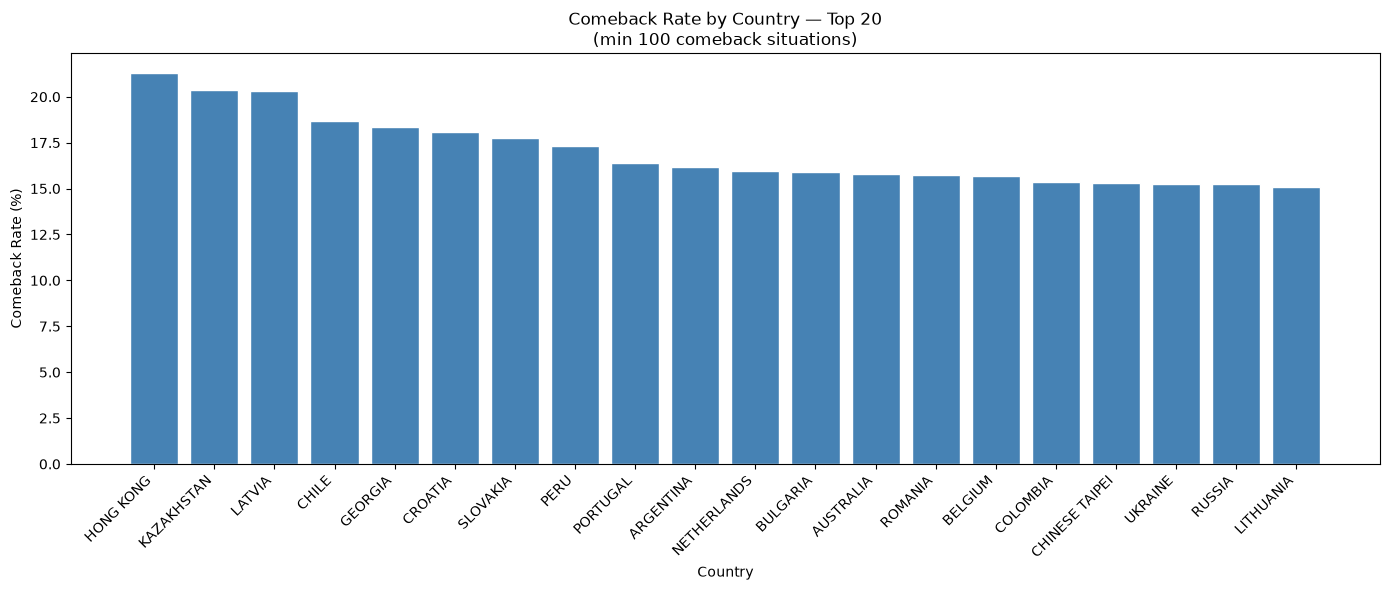

In [17]:
home_team_df = pd.read_csv("../home_team.csv")[["match_id", "current_rank", "country"]].copy()
away_team_df = pd.read_csv("../away_team.csv")[["match_id", "current_rank", "country"]].copy()


def clean_team_df(df):
    df = df.dropna(subset=["match_id", "current_rank"])
    df = df.copy()
    df = df[df["current_rank"] > 0]
    df = df.drop_duplicates(subset=["match_id"])
    return df

home_team_df = clean_team_df(home_team_df)
away_team_df = clean_team_df(away_team_df)

home_country = (
    home_team_df[["match_id", "country"]]
    .dropna(subset=["country"])
    .drop_duplicates(subset=["match_id"])
    .rename(columns={"country": "home_country"}))

away_country = (
    away_team_df[["match_id", "country"]]
    .dropna(subset=["country"])
    .drop_duplicates(subset=["match_id"])
    .rename(columns={"country": "away_country"}))

comebacks_country = (
    comebacks
    .merge(home_country, on="match_id", how="inner")
    .merge(away_country, on="match_id", how="inner"))

print(f"Matches after merging with country data: {len(comebacks_country):,}")


home_rows = comebacks_country[[
    "match_id", "home_country",
    "home_total_situations", "home_total_converted"
]].rename(columns={
    "home_country":           "country",
    "home_total_situations":  "total_situations",
    "home_total_converted":   "total_converted"})

away_rows = comebacks_country[[
    "match_id", "away_country",
    "away_total_situations", "away_total_converted"
]].rename(columns={
    "away_country":           "country",
    "away_total_situations":  "total_situations",
    "away_total_converted":   "total_converted"})

player_country_df = pd.concat([home_rows, away_rows], ignore_index=True)

player_country_df["country"] = player_country_df["country"].str.strip().str.upper()
player_country_df = player_country_df.dropna(subset=["country"])
player_country_df = player_country_df[player_country_df["total_situations"] > 0]

print(f"Total player-match appearances in a comeback situation: {len(player_country_df):,}")


result_country_all = (player_country_df
    .groupby("country")
    .agg(
        total_situations=("total_situations", "sum"),
        total_converted=("total_converted",   "sum"))
    .reset_index()
    .assign(
        comeback_rate=lambda d: (
            d["total_converted"] / d["total_situations"] * 100)
            .round(2)))


print(f"\nTotal countries before filter : {len(result_country_all):,}")
print(f"Countries with fewer than 20 situations  : {(result_country_all['total_situations'] < 20).sum():,}")
print(f"Countries with fewer than 100 situations : {(result_country_all['total_situations'] < 100).sum():,}")


MIN_SITUATIONS = 100

result_country = (
    result_country_all[result_country_all["total_situations"] >= MIN_SITUATIONS]
    .sort_values("comeback_rate", ascending=False)
    .reset_index(drop=True))

total_situations_final = result_country["total_situations"].sum()
total_converted_final  = result_country["total_converted"].sum()

print(f"\nCountries after filter (>= {MIN_SITUATIONS} situations) : {len(result_country):,}")
print(f"Total situations in final analysis                      : {total_situations_final:,}")
print(f"Total comebacks made in final analysis                  : {total_converted_final:,}")
print(f"Overall comeback rate                                   : {(total_converted_final / total_situations_final * 100):.2f}%")

print("  \nTotal Comebacks by Country:\n(sorted by comeback rate)")
print(result_country.to_string(index=False))


top20 = result_country.head(20)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    top20["country"],
    top20["comeback_rate"],
    color="steelblue",
    edgecolor="white")

ax.set_title(f"Comeback Rate by Country — Top 20\n(min {MIN_SITUATIONS} comeback situations)")
ax.set_xlabel("Country")
ax.set_ylabel("Comeback Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Explanation
Hong Kong had the highest comeback rate at about **21%**, while Lithuania had the lowest at about **15%**. Overall, the comeback rates were fairly close across the top 20 countries. As we can see, none of the top three most successful countries from Question 6 (America, France, and Italy) are in the top 20 for comeback rate. This may suggest that staying ahead is more important for success than making a comeback.
